In [1]:
import lipd as lpd
import pandas as pd
import xarray as xr
import pyleoclim.utils.lipdutils as lipdutils
import numpy as np
from PyAstronomy import pyasl
from datetime import datetime
from collections import OrderedDict
from dateutil import parser

In [22]:
#Open the Lipd file - Note Lipd utils only take full path-Pyleoclim goes around it
d = lpd.readLipd('/Users/deborahkhider/Documents/GitHub/pylipd/Ocn-Vanuatu.Gorman.2012.lpd')
d

Disclaimer: LiPD files may be updated and modified to adhere to standards

reading: Ocn-Vanuatu.Gorman.2012.lpd
Finished read: 1 record


{'@context': 'context.jsonld',
 'archiveType': 'coral',
 'createdBy': 'matlab',
 'dataContributor': 'MNE, CS',
 'dataSetName': 'Ocn-Vanuatu.Gorman.2012',
 'googleDataURL': 'https://docs.google.com/spreadsheets/d/1xEIUlQAiPNMSMvwDHqaZEqCEqHY4ZrKZZIwvTpphE7s',
 'googleMetadataWorksheet': 'ojvgued',
 'googleSpreadSheetKey': '1xEIUlQAiPNMSMvwDHqaZEqCEqHY4ZrKZZIwvTpphE7s',
 'originalDataURL': 'http://hurricane.ncdc.noaa.gov/pls/paleox/f?p=519:1:0::::P1_STUDY_ID:13439,ftp://ftp.ncdc.noaa.gov/pub/data/paleo/coral/west_pacific/gorman2012.txt,ftp://ftp.ncdc.noaa.gov/pub/data/paleo/coral/west_pacific/gorman2012-rawdata.txt',
 'studyName': 'Gorman2012_Vanuatu',
 'tagMD5': '15aa0bddda4a2108d6e34acca4659136',
 'pub': [{'author': 'Gorman, Meaghan K.;Quinn, Terrence M.;Taylor, Frederick W.;Partin, Judson W.;Cabioch, Guy;Austin, James A.;Pelletier, Bernard;Ballu, Valérie;Maes, Christophe;Saustrup, Steffen',
   'citeKey': 'gorman2012acoralbasedreconstruction',
   'dataUrl': 'doi.org',
   'issue': '3',


In [30]:
ts = lpd.extractTs(d)
ts[0]['archiveType']

extracting paleoData...
extracting: Ocn-Vanuatu.Gorman.2012
Created time series: 3 entries


'coral'

In [9]:
d.keys()

dict_keys(['@context', 'archiveType', 'createdBy', 'dataContributor', 'dataSetName', 'googleDataURL', 'googleMetadataWorksheet', 'googleSpreadSheetKey', 'originalDataURL', 'studyName', 'tagMD5', 'pub', 'geo', 'paleoData', 'lipdVersion'])

Function to extract the information from a LiPD file and create a pandas dataframe.
Note: This is tailored to the data, will need to become more general. 

In [7]:
#def get_dataframe(d):
csv = lpd.getCsv(d)
chronMeasurementTables, paleoMeasurementTables = lipdutils.isMeasurement(csv)
#ignore chron for now.
table_key = paleoMeasurementTables[0].split('.')[-2]
# Measurement dict
paleoData = d['paleoData']['paleo0']['measurementTable'][table_key]['columns']
# Key over to get the headers.
headers = []
val=[]
for item in paleoData.keys():
    if item != 'year': #this would have to be expanded to age or any combination
        headers.append(item)
        val.append(np.array(paleoData[item]['values']))
    elif item == 'year':
        indices = paleoData[item]['values']
        date_time = []
        for item in indices:
            date_time.append(parser.parse(pyasl.decimalYearGregorianDate(item,"yyyy-mm-dd")))
        dti = pd.to_datetime(date_time)
#create Series
#series_dict = OrderedDict()
#series_dict[d['dataSetName']] = OrderedDict() #handle multiple Lipd files into one object
#for idx,item in enumerate(headers):
#    series_dict[d['dataSetName']][item] = pd.Series(val[idx],dti)
sl=[]
for idx, item in enumerate(headers):
    sl.append(pd.Series(val[idx],dti))
df = pd.DataFrame({'d18O':sl[0],'d13C':sl[1]})

In [9]:
metadata = {'archivetype':'Coral', 'geo':{'coordinates':[2,2,2]}}
metadata

{'archivetype': 'Coral', 'geo': {'coordinates': [2, 2, 2]}}

In [17]:
df.attrs.update({'metadata':metadata})

In [21]:
df.attrs['metadata']

{'archivetype': 'Coral', 'geo': {'coordinates': [2, 2, 2]}}

In [ ]:
# warning: pseudocode
class Lipd():
    def __init__(self):
        ### TO DO: Insert above code
        
        ### initialize
        #self.lipd_dict=d
        self.dataframe=super(pd.DataFrame(series_dict))

In [23]:
df

,d18O,d13C
2007-08-17,-4.930000,-2.070000
2007-07-17,-5.084667,-2.341584
2007-06-17,-5.155617,-2.309383
2007-05-17,-5.175080,-2.091698
2007-04-17,-5.192504,-2.005719
...,...,...
1842-12-16,-4.647195,-0.758541
1842-11-16,-4.643285,-1.117972
1842-10-16,-4.595265,-1.280264
1842-09-16,-4.423366,-1.220409


<AxesSubplot:>

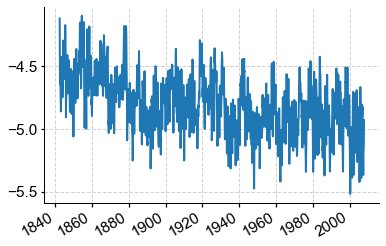

In [24]:
sl[0].plot()

In [26]:
df2 = pd.DataFrame({'example':np.array([[2,3,4],[4,5,6]])})

ValueError: If using all scalar values, you must pass an index

<AxesSubplot:>

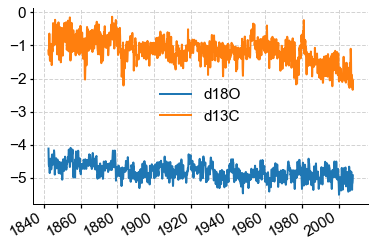

In [27]:
df.plot()